# Visualisation des modèles

*Petit paragraphe de présentaion ?*

In [14]:
import numpy as np
#from scipy.optimize import linprog
#import pandas as pd
#import pulp
#import networkx as nx
import matplotlib.pyplot as plt
#from ipywidgets import interact, IntSlider

import fonctions_communes as fct
import fonctions_complet as com
import fonctions_separe as sep
import fonctions_affichage as aff

## 1. Choix des paramètres de simulation et chargement des données

### 1.1. Choix des paramètres de simulation

In [15]:
N = 5 # nombre de pays simulés

phs_capacity = 30*180 # modifié en faisant 30*
phs_power = 5*9.3 # modifié en faisant 5*
phs_eff=0.75 
ptg_capacity = 125000
ptg_init_rate = 0.75 # taux initial de remplissage des stocks (entre 0 et 1)
ptg_power_in = 60*7.66 # modifié en faisant 60*
ptg_power_out = 2*32.93 # modifié en faisant 2*
ptg_eff = 0.4
# Seulement pour le SEPARE :
penalisation = 1e10
flux_eff = 0.9

### 1.2. Chargement des données

Chargement des données pour 1 pays du code jouet et définition des capacités requises :

In [16]:
df_demand, df_solar, df_wind, solar_capacity, wind_capacity = fct.charge_data()

Capacités requises: éolien = 297.6GW, solaire = 539.7GW


Transformation pour simuler N pays différents :

In [17]:
demand_N, solar_N, wind_N, solar_cap_N, wind_cap_N = fct.transfo_multipays(df_demand, df_solar, df_wind, solar_capacity, wind_capacity, N)

Chargement des capacité d'échange maximales :

In [18]:
qmax7pays = fct.capa_max_echanges()
qmax = 10*qmax7pays[:N,:N]
print("Matrice des capacités d'échanges max :", qmax, sep='\n')

Matrice des capacités d'échanges max :
[[ 0.  9.  4. 17.  2.]
 [11.  0.  0.  0.  0.]
 [35.  0.  0. 20.  0.]
 [17.  0. 28.  0.  0.]
 [18.  0.  0. 24.  0.]]


### 1.3 Choix des paramètres d'affichage

## 2. Simulation des modèles "Complet" et "Séparé" sur 1 an

### 2.1. Complet

In [19]:
result = com.optimize(
    wind_profile=wind_N,
    solar_profile=solar_N,
    demand=demand_N,
    wind_cap=wind_cap_N,
    solar_cap=solar_cap_N,
    qmax_matrix=qmax,
    phs_capacity=phs_capacity, 
    phs_power=phs_power, 
    phs_eff=phs_eff,  
    ptg_capacity=ptg_capacity,
    ptg_init_rate=ptg_init_rate,
    ptg_power_in=ptg_power_in,
    ptg_power_out=ptg_power_out,
    ptg_eff=ptg_eff
)

Interprétation graphique :

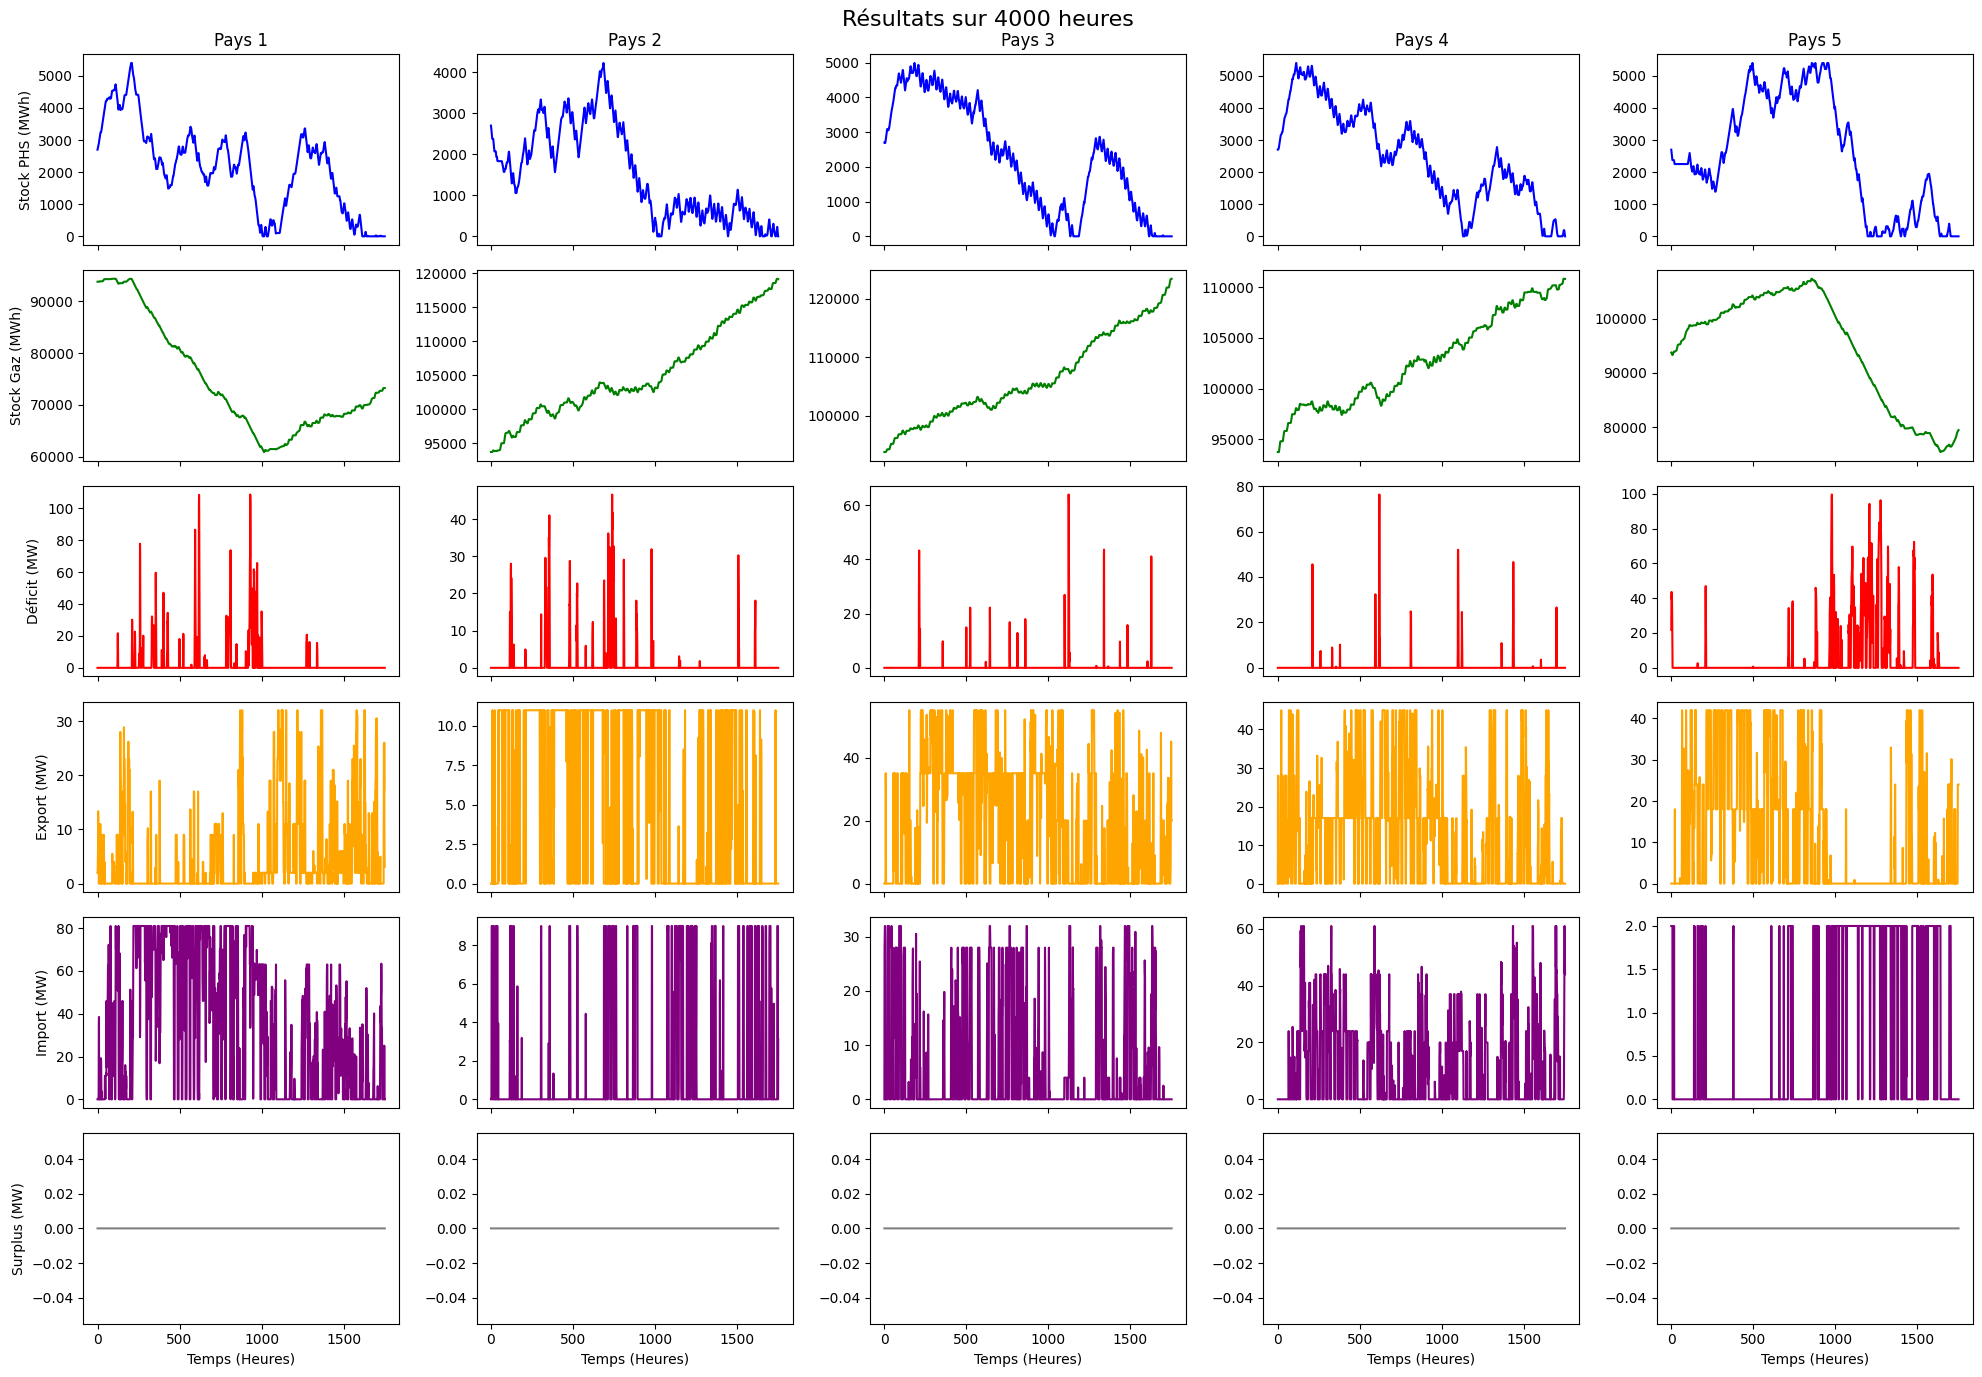

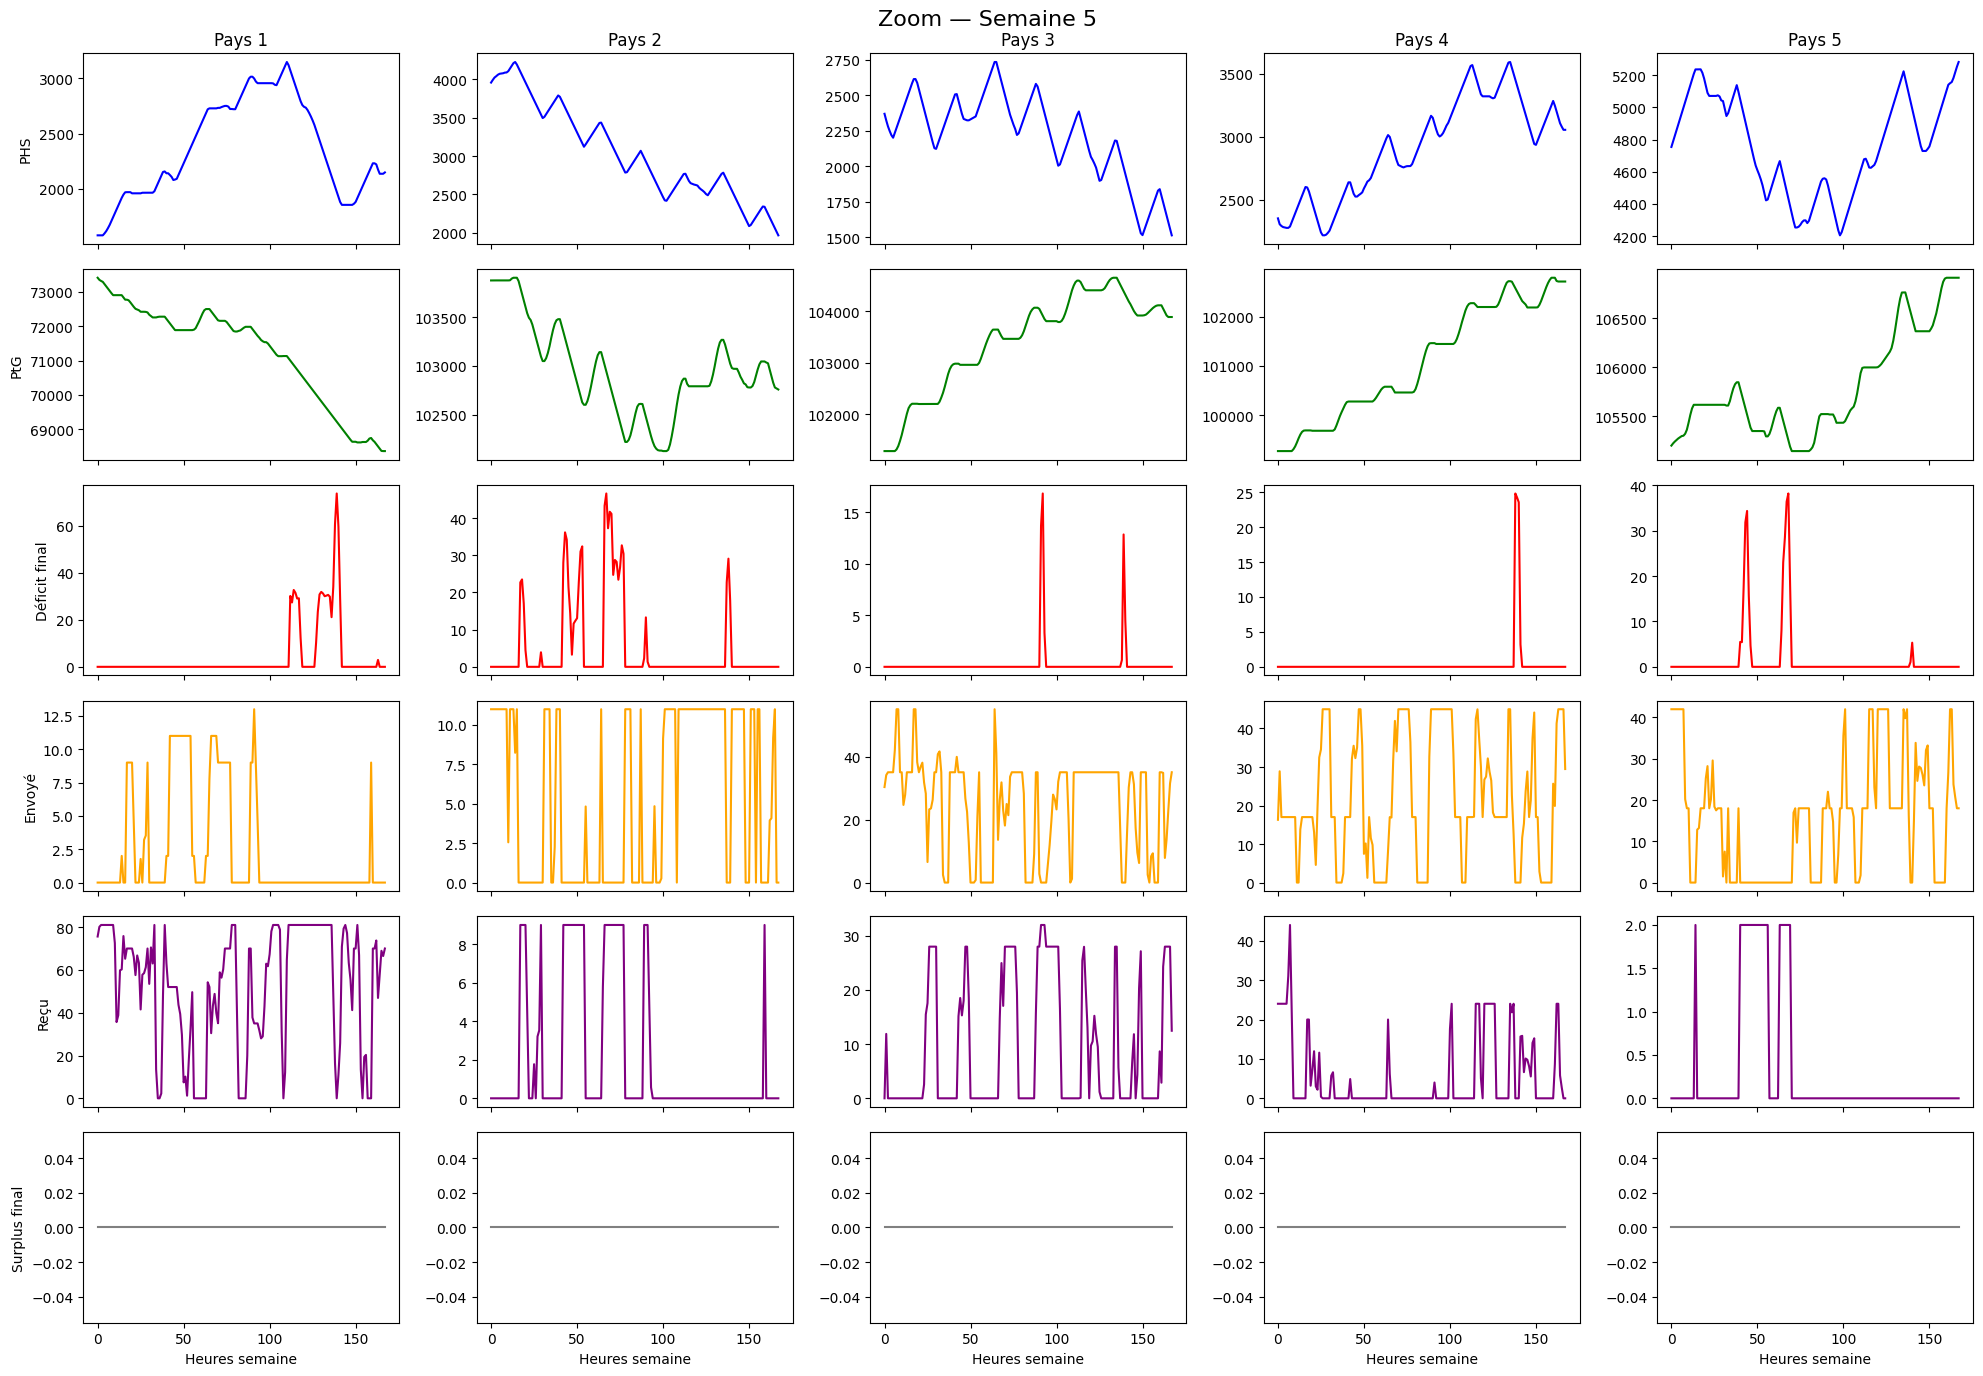

In [20]:
aff.plot_graphs(result)

In [21]:
aff.plot_global_graph(result, demand_N=demand_N, wind_N=wind_N, wind_cap_N=wind_cap_N, solar_N=solar_N, solar_cap_N=solar_cap_N, ptg_eff=ptg_eff, phs_eff=phs_eff)

TypeError: plot_global_graph() got an unexpected keyword argument 'ptg_eff'

### 2.2 Séparé

In [ ]:
# Utilisation de la V3

result = sep.optimize3(
    wind_profile=wind_N,
    solar_profile=solar_N,
    demand=demand_N,
    wind_cap=wind_cap_N,
    solar_cap=solar_cap_N,
    qmax_matrix=qmax,
    phs_capacity=phs_capacity, 
    phs_power=phs_power, 
    phs_eff=phs_eff,  
    ptg_capacity=ptg_capacity,
    ptg_init_rate=ptg_init_rate,
    ptg_power_in=ptg_power_in,
    ptg_power_out=ptg_power_out,
    ptg_eff=ptg_eff,
    penalisation=penalisation,
    flux_eff=flux_eff
)


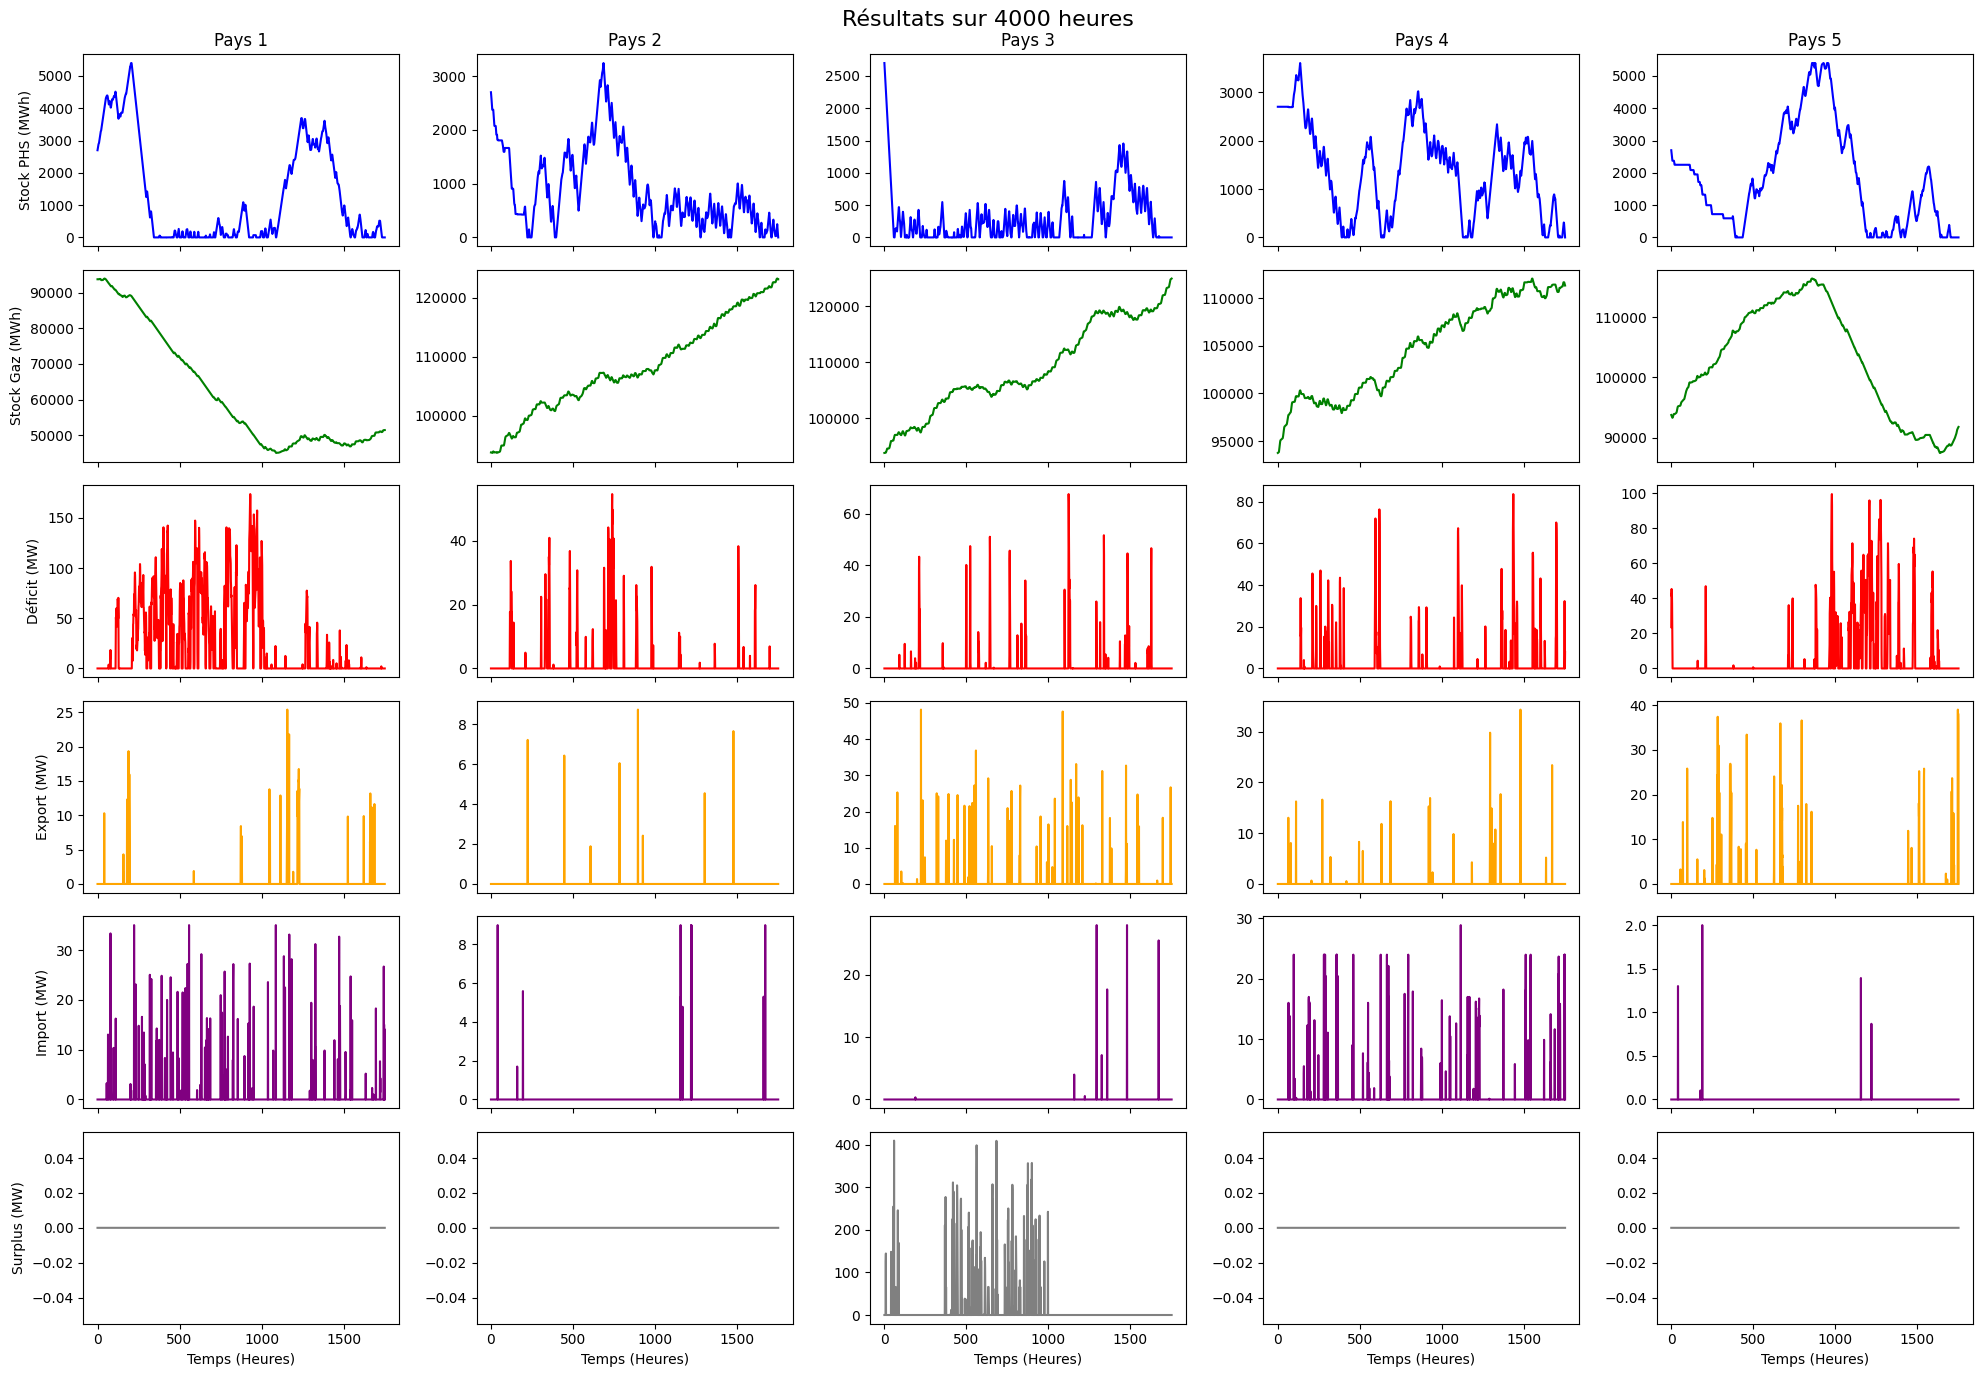

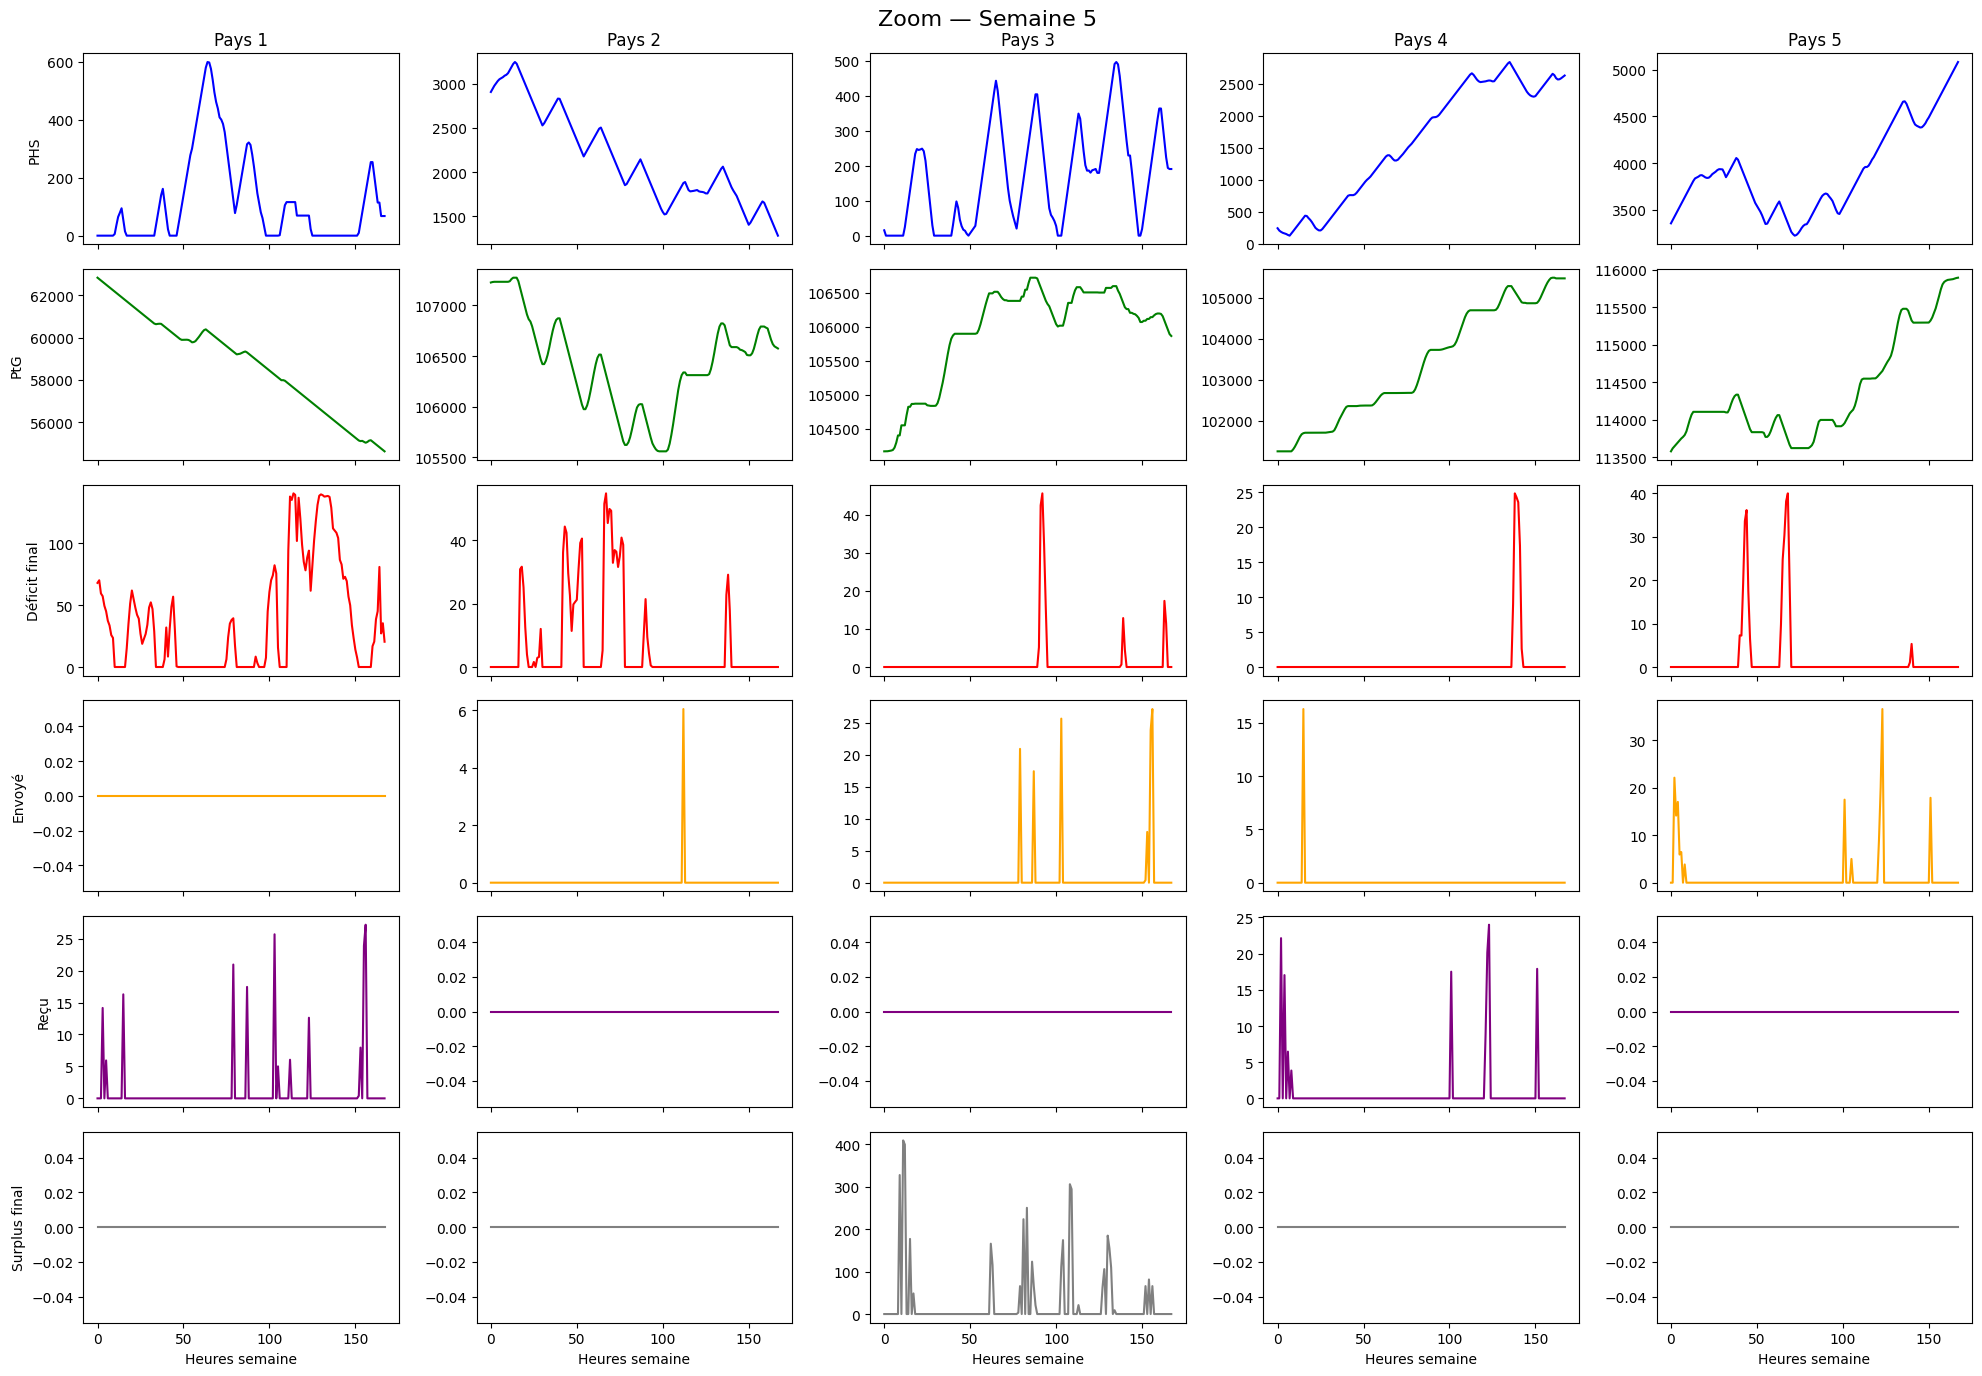

In [ ]:
aff.plot_graphs(result)

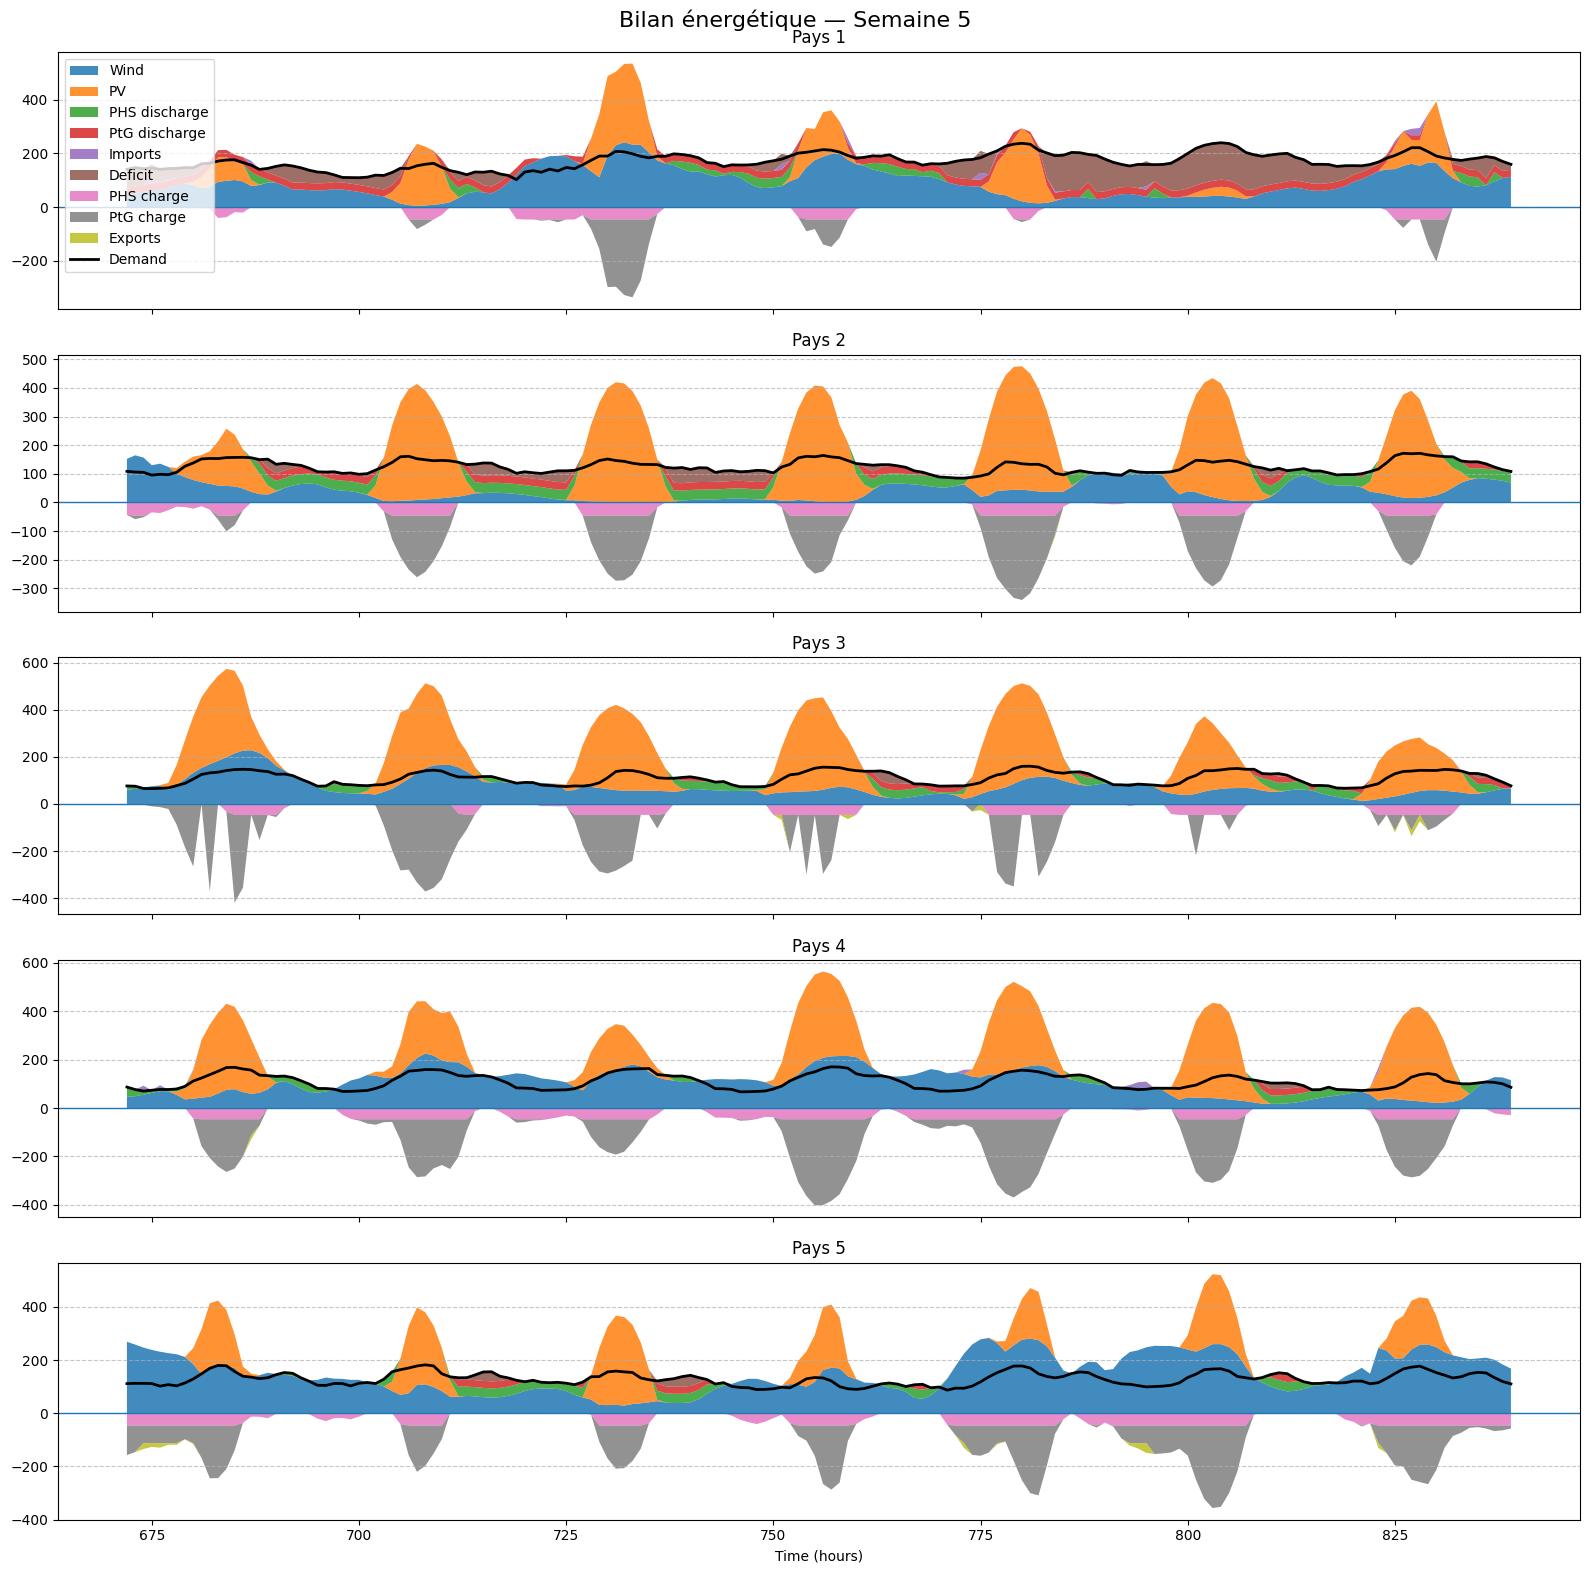

In [ ]:
aff.plot_global_graph(result, demand_N=demand_N, wind_N=wind_N, wind_cap_N=wind_cap_N, solar_N=solar_N, solar_cap_N=solar_cap_N)

## 3. Simulation des modèles "Complet" et "Séparé" sur 5 an

## Complet 5 ans

## Séparé 5ans